## Урок 6. Домашнее задание

### 6.1 Задание начального уровня

**Задание просто уровня** Дана матрица $A$, вычислите SVD разложение с помощью функции `numpy.linalg.svd`. Найдите [определитель](https://ru.wikipedia.org/wiki/Определитель ) матрицы $U$ с помощью функции `numpy.linalg.det`. Чему равен определитель?

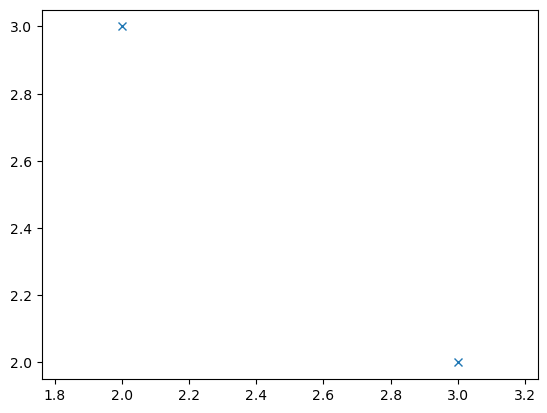

In [3]:
from numpy.linalg import svd, det
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

A = np.array([[3,2,2],[2,3,-2]])
#визуализация исходных данных
plt.plot(A[:,0], A[:,1], 'x')
plt.axis('equal')
plt.show()


In [26]:
from numpy.linalg import svd, det
#вычисляем SVD разложение
U, s, Vt = svd(A)

In [27]:
#вычисляем определитель матрицы U
det_U = det(U)
print(f"Определитель U: {det_U}")

Определитель U: 0.9999999999999997


In [28]:
!pip install Pillow

### 6.2 Задание высокого уровня

В домашней работе предлагаю Вам немного поработать с изображениями (похожий трюк можно увидеть в этой [статье на хабре](https://habr.com/ru/post/275273/)). Для этого нужно установить модуль Pillow (если у вас Анаконда, то https://anaconda.org/anaconda/pillow)

<pre>
pip install Pillow
</pre>

Загрузим картинку в трёхмерный *numpy array* и отобразим её прямо в jupyter notebook.

<class 'numpy.ndarray'> (380, 509, 3)


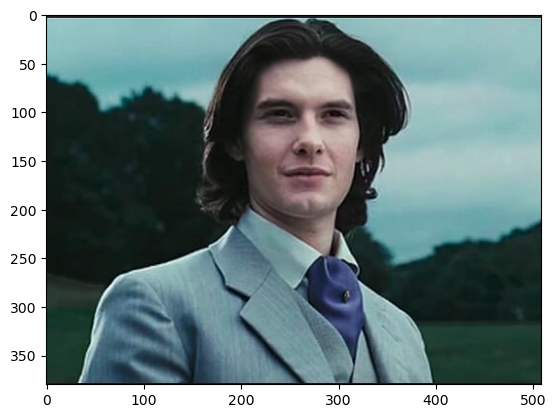

In [31]:
from matplotlib.pyplot import imshow
import matplotlib.image as mpimg
file_path = 'C:/Users/user0907/dorian_grey.png'
#with open(file_path, 'rb') as img:
img = mpimg.imread(file_path)
print(type(img),img.shape)
imshow(img)
plt.show()

У нас трёхмерный массив, где третье измерение соответствует цветовой компоненте rgb. Цветную картинку можно преобразовать в двумерную серую (grayscale) с помощью формулы, которую я нашёл [тут](https://stackoverflow.com/questions/12201577/how-can-i-convert-an-rgb-image-into-grayscale-in-python)

<class 'numpy.ndarray'> (380, 509)


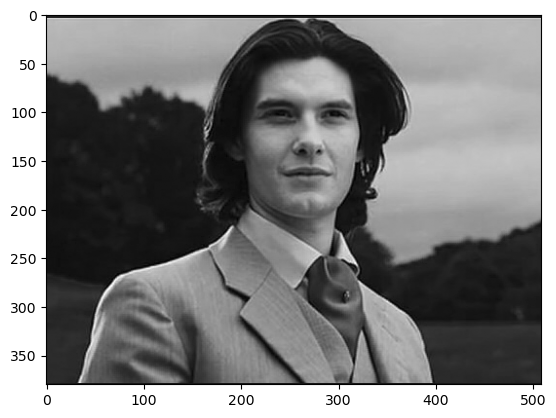

In [39]:
def rgb2gray(rgb):
    ''' Берётся среднее трёх цветов RGB'''
    tile = np.tile(np.c_[0.333, 0.333, 0.333], reps=(rgb.shape[0], rgb.shape[1], 1))
    return np.sum(tile * rgb, axis=2)

img_gray = rgb2gray(img)
print(type(img_gray), img_gray.shape)
plt.imshow(img_gray, cmap = "gray")
plt.show()

Далее

* обучите на массиве *img_gray* размерности $894 \times 588$ класс TruncatedSVD c параметром n_components=5
* получите матрицу *img_gray_svd* с помощью функции `transform`
* получите массив *img_gray_svd_restored* с помощью функции `inverse_transform`
* визуализируйте массив *img_gray_svd_restored* с помощью функции *imshow*

Этот алгоритм демонстрирует, как происходит сжатие данных большой размерности. А результате у вас должна получится фотка как бы в очень нечётком виде

![grey_pca.png](https://248006.selcdn.ru/public/DS.%20Block%202.%20M8/grey_pca.png)

In [40]:
from sklearn.decomposition import TruncatedSVD
# понижвем размерность
# получаем SVD разложение
svd_model = TruncatedSVD(n_components=5).fit(img_gray)
# применяем преобразование к исходным данным
img_gray_svd = svd_model.transform(img_gray)
# трансформируем данные обратно к исходному пространству
img_gray_svd_restored = svd_model.inverse_transform(img_gray_svd)
# визуализируем то, что получилось


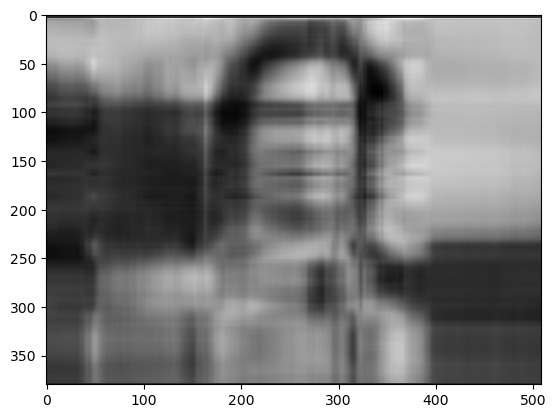

In [42]:
# визуализируем то, что получилось
plt.imshow(img_gray_svd_restored, cmap = "gray")
plt.show()

В этом уроке мы познакомились с таким способом снижения размерности, как PCA. Оба метода которые мы же значем выполняют сжатие как линейное преобразование. В следующем уроке рассмотрим нелинейное сжатие